In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# 定义 LSTM RUL 预测器
class LSTMRULPredictor(nn.Module):
    def __init__(self):
        super(LSTMRULPredictor, self).__init__()
        self.lstm = nn.LSTM(input_size=14, hidden_size=64, num_layers=2, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x, _ = self.lstm(x)  # LSTM输出
        x = x[:, -1, :]  # 取最后一个时间步的输出
        x = self.fc(x)  # 全连接层
        return x


# 定义数据集类
class NCMAPSSDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe
        self.sensor_columns = ['T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc',
                               'Wf']
        self.data = []

        for _, row in self.dataframe.iterrows():
            sensor_data = row[self.sensor_columns].values.astype(np.float32)
            rul = row['RUL'] / 100.0  # 除以100处理
            unit = row['unit']  # 获取发动机编号
            self.data.append((sensor_data, rul, unit))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sensor_data, rul, unit = self.data[idx]
        return torch.tensor(sensor_data, dtype=torch.float32), torch.tensor(rul, dtype=torch.float32), unit


# 读取更新后的数据集
data = pd.read_csv('N-CMAPSS_DS02_processed_sampled_no_normalization.csv')

# 整体归一化传感器数据
for column in ['T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf']:
    mean = data[column].mean()
    std = data[column].std()
    data[column] = (data[column] - mean) / std

# 创建数据集和数据加载器
dataset = NCMAPSSDataset(data)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 初始化模型
lstm_rul_predictor = LSTMRULPredictor()

# 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(lstm_rul_predictor.parameters(), lr=0.0001)


# 训练过程
def train_rul_predictor(lstm_rul_predictor, dataloader, num_epochs=20):
    for epoch in range(num_epochs):
        lstm_rul_predictor.train()

        for sensor_data, rul, unit in dataloader:
            sensor_data = sensor_data.unsqueeze(1)  # 添加时间步维度
            optimizer.zero_grad()
            rul_pred = lstm_rul_predictor(sensor_data)
            loss = criterion(rul_pred, rul.unsqueeze(1))  # 添加维度
            loss.backward()
            optimizer.step()

        print(f"Epoch [{epoch + 1}/{num_epochs}], RUL Loss: {loss.item():.4f}")


# 运行 LSTM RUL 预测器的训练
train_rul_predictor(lstm_rul_predictor, dataloader, num_epochs=2)


# 进行预测并还原RUL
def predict_rul(lstm_rul_predictor, dataset):
    lstm_rul_predictor.eval()
    predictions = []
    actuals = []
    units = []

    with torch.no_grad():
        for sensor_data, rul, unit in dataset:
            sensor_data = sensor_data.unsqueeze(0).unsqueeze(1)  # 添加批量维度和时间步维度
            rul_pred = lstm_rul_predictor(sensor_data)
            predictions.append(rul_pred.item())
            actuals.append(rul.item())
            units.append(unit.item())

    return predictions, actuals, units


# 进行RUL预测
predictions, actuals, units = predict_rul(lstm_rul_predictor, dataset)

# 将预测值和实际值还原到原始RUL（乘以100）
predictions = [pred * 100 for pred in predictions]
actuals = [actual * 100 for actual in actuals]


# 绘制结果
def plot_rul(predictions, actuals, units):
    df = pd.DataFrame({'Predicted RUL': predictions, 'Actual RUL': actuals, 'Unit': units})
    unique_units = df['Unit'].unique()

    for unit in unique_units:
        unit_data = df[df['Unit'] == unit].reset_index(drop=True)
        plt.figure(figsize=(10, 5))
        plt.plot(unit_data.index, unit_data['Predicted RUL'], label='Predicted RUL', color='blue')
        plt.plot(unit_data.index, unit_data['Actual RUL'], label='Actual RUL', color='red')
        plt.title(f'RUL Prediction vs Actual for Engine Unit {unit}')
        plt.xlabel('Sample Index')
        plt.ylabel('Remaining Useful Life (RUL)')
        plt.xlim(0, len(unit_data) - 1)  # 横轴从0开始
        plt.ylim(0, max(max(predictions), max(actuals)))  # 纵轴为RUL的原始范围
        plt.legend()
        plt.grid()
        plt.show()


# 绘制RUL预测与实际值的图
plot_rul(predictions, actuals, units)


KeyboardInterrupt: 

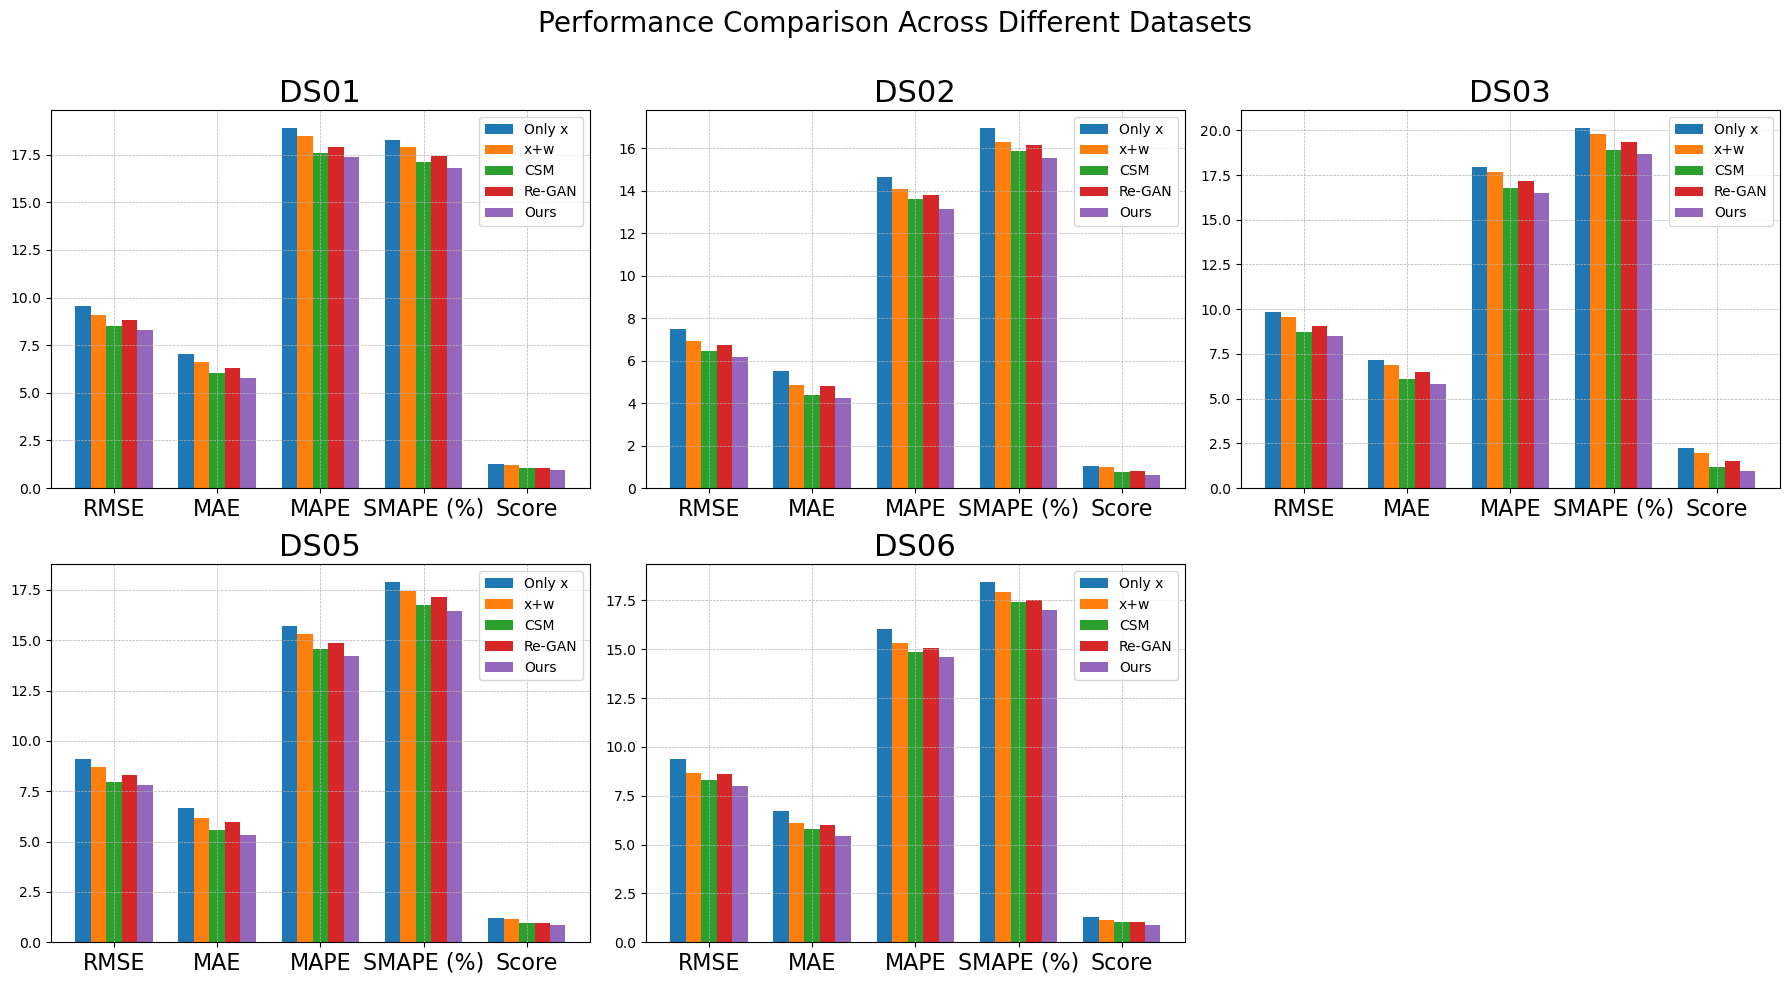

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 构建表格数据
data = {
    "Dataset": ["DS01", "DS01", "DS01", "DS01", "DS01",
                "DS02", "DS02", "DS02", "DS02", "DS02",
                "DS03", "DS03", "DS03", "DS03", "DS03",
                "DS05", "DS05", "DS05", "DS05", "DS05",
                "DS06", "DS06", "DS06", "DS06", "DS06"],
    "Method": ["Only x", "x+w", "CSM", "Re-GAN", "Ours"] * 5,
    "RMSE": [9.54, 9.07, 8.49, 8.80, 8.27, 
             7.51, 6.92, 6.44, 6.73, 6.17,
             9.84, 9.55, 8.70, 9.07, 8.49,
             9.10, 8.72, 7.98, 8.33, 7.82,
             9.38, 8.66, 8.30, 8.60, 8.00],
    "MAE": [7.06, 6.62, 6.04, 6.32, 5.78,
            5.49, 4.84, 4.39, 4.82, 4.23,
            7.16, 6.90, 6.10, 6.50, 5.80,
            6.69, 6.18, 5.60, 5.97, 5.35,
            6.74, 6.13, 5.82, 6.01, 5.42],
    "MAPE": [18.90, 18.46, 17.59, 17.92, 17.38,
             14.65, 14.08, 13.62, 13.80, 13.14,
             17.95, 17.67, 16.77, 17.14, 16.49,
             15.69, 15.33, 14.58, 14.87, 14.22,
             16.04, 15.34, 14.86, 15.09, 14.60],
    "SMAPE (%)": [18.26, 17.91, 17.10, 17.43, 16.78,
                  16.96, 16.28, 15.87, 16.14, 15.56,
                  20.13, 19.79, 18.90, 19.35, 18.66,
                  17.88, 17.46, 16.76, 17.17, 16.45,
                  18.43, 17.92, 17.43, 17.52, 17.03],
    "Score": [1.25, 1.23, 1.03, 1.06, 0.93,
              1.06, 1.01, 0.76, 0.80, 0.61,
              2.22, 1.98, 1.19, 1.50, 0.97,
              1.20, 1.15, 0.94, 0.97, 0.84,
              1.29, 1.14, 1.03, 1.06, 0.86]
}

# 将数据转换为 DataFrame
df = pd.DataFrame(data)

# 定义图表的布局和大小
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2 行 3 列布局
fig.suptitle("Performance Comparison Across Different Datasets", fontsize=20)

# 获取所有数据集
datasets = df["Dataset"].unique()

# 针对每个数据集绘制柱状图
for i, dataset in enumerate(datasets):
    # 筛选出对应数据集的数据
    subset = df[df["Dataset"] == dataset]
    metrics = ["RMSE", "MAE", "MAPE", "SMAPE (%)", "Score"]
    
    # 每个方法在不同指标上的值
    values = subset[metrics].values
    method_labels = subset["Method"].values

    # 计算子图的位置
    row, col = divmod(i, 3)
    ax = axes[row, col]

    # 设置柱状图参数
    bar_width = 0.15  # 每个柱子的宽度
    index = np.arange(len(metrics))  # 性能指标的数量

    # 绘制每个方法在不同指标上的表现
    for j, (method, val) in enumerate(zip(method_labels, values)):
        ax.bar(index + j * bar_width, val, bar_width, label=method)

    # 设置子图的标签和标题
#     ax.set_xlabel("Metrics", fontsize=14)
#     ax.set_ylabel("Values", fontsize=14)
    ax.set_title(f"{dataset}", fontsize=22)
    ax.set_xticks(index + bar_width * 2)
    ax.set_xticklabels(metrics, fontsize=16)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.5)
fig.delaxes(axes[-1, -1])  # 删除最后一个空白子图

# 调整布局
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()
